In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loan Approval Dataset

`About This Data`

- This dataset contains financial and demographic information on 1,000 loan applicants, designed to facilitate the development of machine learning models for credit risk assessment and loan approval prediction. It includes key features such as annual income, credit score, loan amount, number of dependents, and employment status. The target variable, loan_approved, indicates whether a loan was granted (1) or denied (0). This dataset is ideal for practicing binary classification, data visualization, and exploratory data analysis (EDA) within the banking and finance domain.

## Column Types:-
`Numerical Columns`- annual_income, loan_amount, credit_score, existing_loans_count

`Categorical Columns`- age, gender, marital_status, employment_status, loan_approved

In [4]:
# Import dataset

df = pd.read_csv('loanapproval.csv')

In [5]:
# see Dataset

df

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1
...,...,...,...,...,...,...,...,...,...,...,...
995,996,53,Female,Married,135598,6014,767,3,2,Employed,1
996,997,22,Male,Single,139028,15103,662,0,0,Self-employed,1
997,998,34,Female,Married,147517,21986,582,0,2,Employed,1
998,999,60,Female,Divorced,73161,49781,635,4,0,Unemployed,1


In [6]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [7]:
df.tail()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
995,996,53,Female,Married,135598,6014,767,3,2,Employed,1
996,997,22,Male,Single,139028,15103,662,0,0,Self-employed,1
997,998,34,Female,Married,147517,21986,582,0,2,Employed,1
998,999,60,Female,Divorced,73161,49781,635,4,0,Unemployed,1
999,1000,60,Female,Single,141316,35471,461,1,1,Unemployed,1


In [10]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [57]:
approval_rate = df['loan_approved'].value_counts(normalize=True)*100
approval_rate

loan_approved
1    72.9
0    27.1
Name: proportion, dtype: float64

In [37]:
df['loan_approved'].unique()

array([1, 0])

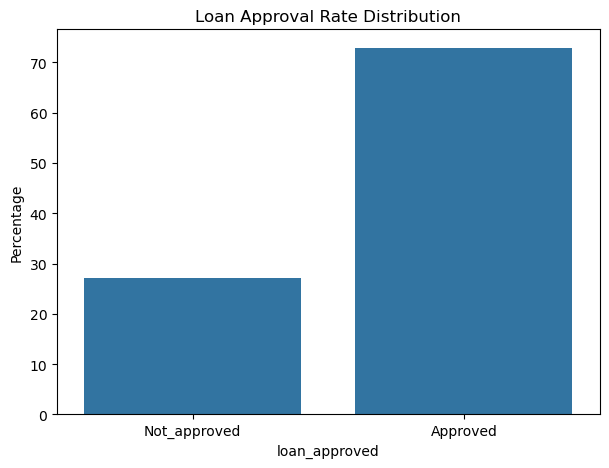

In [54]:
plt.figure(figsize=(7,5))

sns.barplot(x=approval_rate.index, y = approval_rate.values)
# plt.bar(df['loan_approved'].unique(), approval_rate)

plt.xticks(df['loan_approved'].unique(), ['Approved','Not_approved'])
plt.ylabel("Percentage")
plt.title("Loan Approval Rate Distribution")

plt.show()

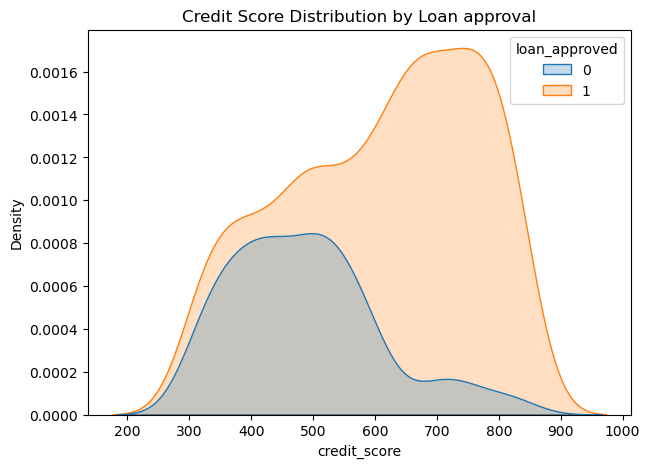

In [95]:
plt.figure(figsize=(7,5))

sns.kdeplot(df, x='credit_score', hue='loan_approved',fill=True)

plt.title('Credit Score Distribution by Loan approval')
plt.show()

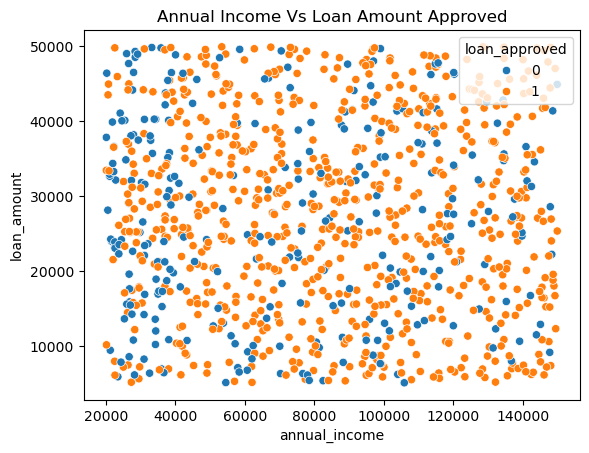

In [97]:
sns.scatterplot(df, x=df['annual_income'], y = df['loan_amount'], hue=df['loan_approved'])

plt.title('Annual Income Vs Loan Amount Approved')
plt.show()

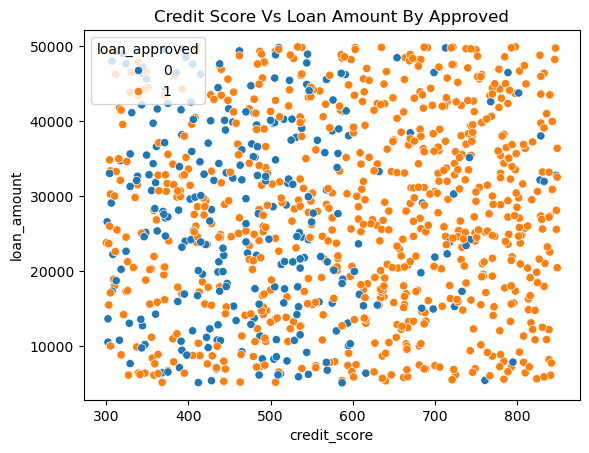

In [100]:
sns.scatterplot(df, x=df['credit_score'], y = df['loan_amount'], hue=df['loan_approved'])

plt.title('Credit Score Vs Loan Amount By Approved')
plt.show()

In [112]:
df['existing_loans_count'].unique()

array([1, 2, 4, 0, 3])

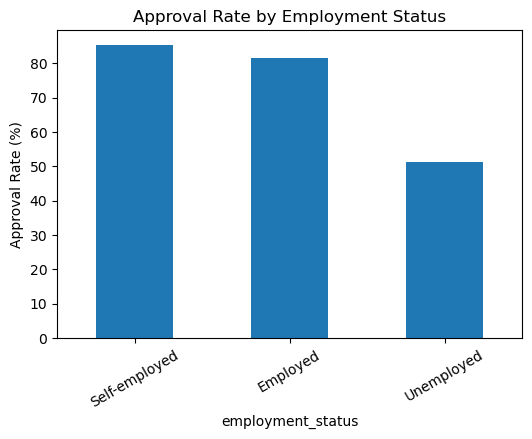

In [128]:
emp_rate = df.groupby("employment_status")["loan_approved"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(6,4))

emp_rate.plot(kind="bar")

plt.ylabel("Approval Rate (%)")
plt.title("Approval Rate by Employment Status")
plt.xticks(rotation=30)
plt.show()

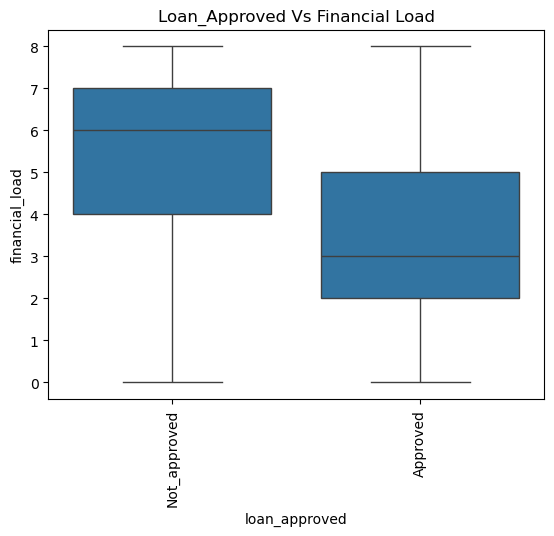

In [142]:
df['financial_load'] = df['num_dependents']+df['existing_loans_count']


sns.boxplot(data=df, x='loan_approved', y='financial_load')

plt.xticks([0,1],['Not_approved','Approved'])
plt.xticks(rotation = 90)

plt.title('Loan_Approved Vs Financial Load')

plt.show()

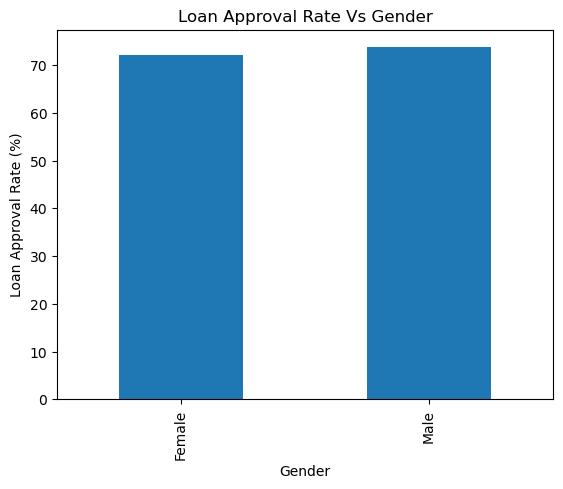

In [156]:
gender_rate = df.groupby('gender')['loan_approved'].mean()*100

gender_rate.plot(kind='bar')

plt.xlabel('Gender')
plt.ylabel('Loan Approval Rate (%)')

plt.title('Loan Approval Rate Vs Gender')

plt.show()

In [158]:
df.head(2)

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved,financial_load
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1,2
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1,2


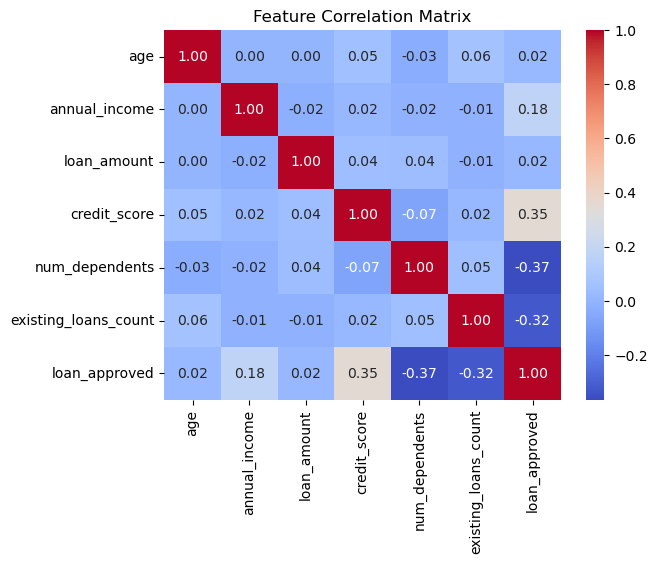

In [172]:
num_cols = ['age','annual_income','loan_amount','credit_score','num_dependents','existing_loans_count','loan_approved']

sns.heatmap(df[num_cols].corr(), annot=True, cmap = 'coolwarm', fmt=".2f")

plt.title('Feature Correlation Matrix')
plt.show()